In [1]:
import pandas as pd

df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")
## ca prend presque 10 mins pour le loading de l'excel vu sa grande taille désolé :/
df_soins = pd.read_excel("C:/Users/hp/Downloads/TER_M1_2025/data/df_all_care_T0_no_filtered.xlsx")
print(" Données de Soins ")
print("Nombre de lignes :", len(df_soins))
print("Colonnes :", df_soins.columns.tolist())
print(df_soins.head())


 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 

 Données de Soins 
Nombre de lignes : 485287
Colonnes : ['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner', 'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan', 'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore', 'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen', 'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part', 'SURG', 'T0', 'TREATMENT_TYPE']
   ID_PATIENT     CODE  DAYS_SINCE_DIAG TABLE_ORIGIN  Cons_Med_Gen  Cons_Spe  \
0  3104503184  D01AC12                0   

In [2]:
df_soins.to_csv("df_soins.csv", index=False)


In [3]:
df_soins = pd.read_csv("df_soins.csv")
df_soins.columns


Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE'],
      dtype='object')

In [4]:
def recoder_prc(classe):
    if classe in [1, 2]:
        return 0  
    elif classe == 3:
        return 1  
    else:
        return None  

df_prc['PRC'] = df_prc['peur_recidive1'].apply(recoder_prc)

In [8]:
df_prc.head(20)

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1
5,1102101659,0
6,1102102186,1
7,1103100275,0
8,1103101510,0
9,1103102437,0


In [9]:
df_prc = df_prc[['ID_PATIENT', 'PRC']]


In [10]:
df_prc.head(5 )

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1


In [11]:
df_merged = df_soins.merge(df_prc, on='ID_PATIENT', how='inner')

In [12]:
df_merged.head(900)

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
0,3104503184,D01AC12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
1,3104503184,G01AF12,0,medic,0,1,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
2,3104503184,N07BA01,4,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
3,3104503184,C509,13,pmsi,0,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
4,3104503184,FCFA021,13,psmi_act,0,0,0,0,0,0,...,0,0,0,0,0,0,1,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,4105904747,9105,1351,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
896,4105904747,QEQM001,1353,ccam,0,0,0,1,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
897,4105904747,QEQK001,1353,ccam,0,0,1,0,0,0,...,0,0,0,0,0,0,0,102,"SURG, RT, HT",0
898,4105904747,L02BG03,1360,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,102,"SURG, RT, HT",0


In [13]:
print("Nombre de patientes uniques :", df_merged['ID_PATIENT'].nunique())


Nombre de patientes uniques : 920


In [14]:
df_post_T0 = df_merged[df_merged["DAYS_SINCE_DIAG"] >= df_merged["T0"]]

In [15]:
df_post_T0

,ID_PATIENT,CODE,DAYS_SINCE_DIAG,TABLE_ORIGIN,Cons_Med_Gen,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Echo_Abdominal,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
235,3104503184,9005,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
236,3104503184,9105,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
237,3104503184,7321,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
238,3104503184,2258,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
239,3104503184,0514,168,bio,1,0,0,0,0,0,...,0,0,0,0,0,0,0,161,"CT, HT, RT, SURG",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485282,4308300843,L02BG03,888,medic,0,1,0,0,0,0,...,0,1,0,0,0,0,0,804,HT,0
485283,3107502798,L02BG03,1060,medic,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1060,HT,1
485284,3107502798,V08AB10,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1
485285,3107502798,V08BA02,1106,medic,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1060,HT,1


In [16]:
df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


C:\Users\hp\AppData\Local\Temp\ipykernel_31116\1400350702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


In [ ]:
actes_suivi = [
    "Cons_Spe",
    "Mammographie", "Echo_Mammaire", "Irm_Mammaire",
    "Fns", "Ca_15_3",
    "Bilan_Hepatique", "Bilan_Lipidique",
    "Echo_pelv", "Echo_endometre",       
    "Osteodensitometrie",               
    "Dosage_pholphocalcique"            
]

In [22]:
df_suivi_filtré = df_post_T0[df_post_T0[actes_suivi].sum(axis=1) >= 1]


In [23]:
print("Nombre d’actes post-T0 pertinents au suivi :", len(df_suivi_filtré))
print(df_suivi_filtré[["ID_PATIENT", "mois_depuis_T0", "PRC"] + actes_suivi].head())


Nombre d’actes post-T0 pertinents au suivi : 76828
     ID_PATIENT  mois_depuis_T0  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
237  3104503184               0    1         0             0              0   
239  3104503184               0    1         0             0              0   
240  3104503184               0    1         0             0              0   
241  3104503184               0    1         0             0              0   
243  3104503184               0    1         0             0              0   

     Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
237             0    0        1                0                0          0   
239             0    0        0                1                0          0   
240             0    0        0                1                0          0   
241             0    0        0                1                0          0   
243             0    0        0                0                0         

In [210]:
## de facon régulière 
def assigner_periode(mois):
    if mois < 0:
        return None
    elif mois < 3:
        return "M0–M3"
    elif mois < 6:
        return "M3–M6"
    elif mois < 9:
        return "M6–M9"
    elif mois < 12:
        return "M9–M12"
    elif mois < 15:
        return "M12–M15"
    elif mois < 18:
        return "M15–M18"
    elif mois < 21:
        return "M18–M21"
    elif mois < 24:
        return "M21–M24"
    elif mois < 27:
        return "M24–M27"
    elif mois < 30:
        return "M27–M30"
    elif mois < 33:
        return "M30–M33"
    elif mois < 36:
        return "M33–M36"
    elif mois < 39:
        return "M36–M39"
    elif mois < 42:
        return "M39–M42"
    elif mois < 45:
        return "M42–M45"
    elif mois < 48:
        return "M45–M48"
    elif mois < 51:
        return "M48–M51"
    elif mois < 54:
        return "M51–M54"
    elif mois < 57:
        return "M54–M57"
    elif mois < 60:
        return "M57–M60"
    else:
        return "M60+"

df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)
df_merged['periode_suivi'] = df_merged['mois_depuis_T0'].apply(assigner_periode)
df_resumé_par_periode = df_merged.groupby(["ID_PATIENT", "periode_suivi", "PRC"])[actes_suivi].sum().reset_index()
print(df_resumé_par_periode.head(10))


C:\Users\hp\AppData\Local\Temp\ipykernel_31116\2564520815.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_suivi_filtré["periode_suivi"] = df_suivi_filtré["mois_depuis_T0"].apply(assigner_periode)


   ID_PATIENT periode_suivi  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
0  1101100325         M0–M3    0        11             1              1   
1  1101100325       M12–M15    0         0             0              0   
2  1101100325       M15–M18    0         0             0              0   
3  1101100325       M18–M21    0         0             0              0   
4  1101100325       M21–M24    0         0             0              0   
5  1101100325       M24–M27    0         0             1              0   
6  1101100325       M27–M30    0         0             0              0   
7  1101100325       M30–M33    0         0             0              0   
8  1101100325       M33–M36    0         1             0              0   
9  1101100325       M36–M39    0         0             1              1   

   Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
0             1    1        0                4                0          0   
1             0   

In [89]:
moyennes_par_prc = df_resumé_par_periode.groupby("PRC")[actes_suivi].mean().T
moyennes_par_prc.columns = ["PRC_0", "PRC_1"]
print(moyennes_par_prc)

                           PRC_0     PRC_1
Cons_Spe                3.971496  4.678677
Mammographie            0.289970  0.274070
Echo_Mammaire           0.267612  0.264619
Irm_Mammaire            0.029517  0.033668
Fns                     0.727322  0.795038
Ca_15_3                 0.264911  0.298582
Bilan_Hepatique         1.568862  1.577673
Bilan_Lipidique         0.257481  0.258417
Echo_pelv               0.056265  0.058181
Echo_endometre          0.192705  0.206143
Osteodensitometrie      0.039581  0.036031
Dosage_pholphocalcique  0.293752  0.305375


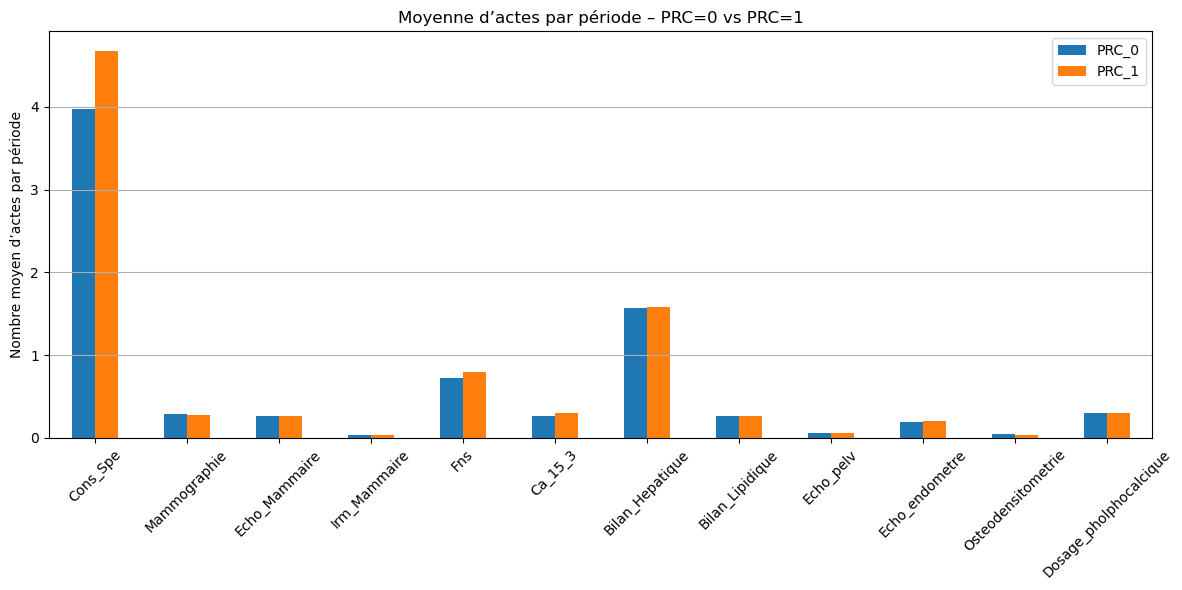

In [90]:
import matplotlib.pyplot as plt

moyennes_par_prc.plot(kind='bar', figsize=(12, 6))
plt.title("Moyenne d’actes par période – PRC=0 vs PRC=1")
plt.ylabel("Nombre moyen d’actes par période")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

 Les patientes du groupe PRC = 1 présentent un suivi  plus intensif, notamment en ce qui concerne les consultations de médecine générale (en moyenne 52 contre 47 actes par période) et les consultations spécialisées. Elles effectuent également plus fréquemment certains bilans biologiques tels que le bilan hépatique ou le dosage du CA 15-3. En revanche, les examens d’imagerie comme la mammographie ou l’IRM mammaire restent globalement équivalents entre les deux groupes

In [20]:
df_post_T0.to_csv("C:/Users/hp/Downloads/df_post_T0.csv", index=False)
df_suivi_filtré.to_csv("C:/Users/hp/Downloads/df_suivi_filtré.csv", index=False)


In [91]:
df_post_T0.columns

Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE', 'PRC', 'mois_depuis_T0'],
      dtype='object')

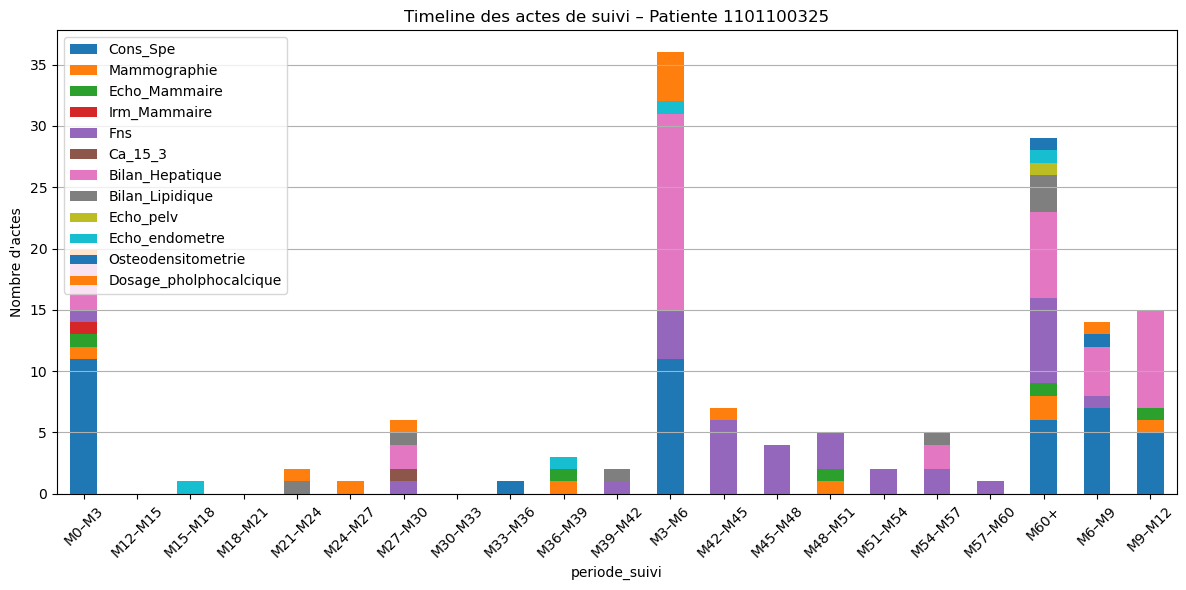

In [92]:

id_exemple = df_resumé_par_periode["ID_PATIENT"].iloc[0]
df_patient = df_resumé_par_periode[df_resumé_par_periode["ID_PATIENT"] == id_exemple]

df_patient.set_index("periode_suivi")[actes_suivi].plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"Timeline des actes de suivi – Patiente {id_exemple}")
plt.ylabel("Nombre d'actes")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [93]:
df_vecteurs = df_resumé_par_periode.copy()
df_vecteurs[actes_suivi] = (df_vecteurs[actes_suivi] > 0).astype(int)


In [94]:
###nécessaire pour faire de l'analyse ou appliquer des modeles ! 
df_vecteurs.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,Echo_pelv,Echo_endometre,Osteodensitometrie,Dosage_pholphocalcique
0,1101100325,M0–M3,0,1,1,1,1,1,0,1,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,1,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,0,0,1,0,0


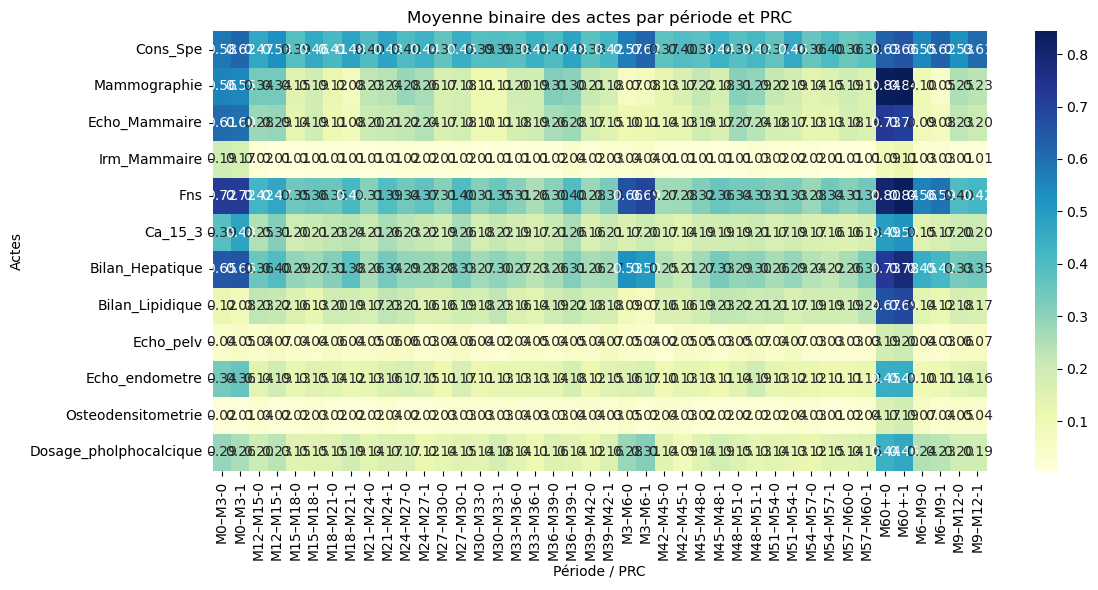

In [95]:
##A diviser entre prc=0 et prc=1

import seaborn as sns

df_heatmap = df_vecteurs.groupby(["periode_suivi", "PRC"])[actes_suivi].mean().T

plt.figure(figsize=(12, 6))
sns.heatmap(df_heatmap, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Moyenne binaire des actes par période et PRC")
plt.ylabel("Actes")
plt.xlabel("Période / PRC")
plt.tight_layout()
plt.show()


Les premières analyses descriptives (moyennes, heatmaps) montrent que les femmes avec PRC=1 présentent un suivi plus fréquent que celles avec PRC=0, en particulier au niveau des consultations médicales et bilans biologiques, dès les premiers mois post-traitement.

<AxesSubplot:>

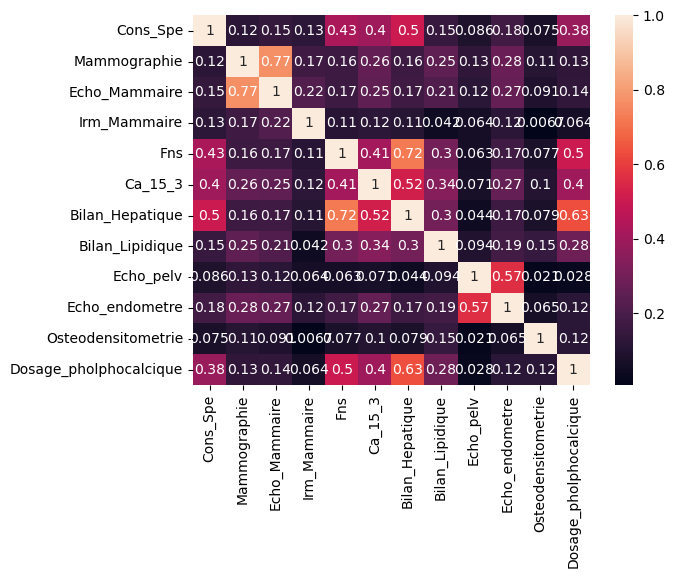

In [96]:
corr = df_resumé_par_periode[actes_suivi].corr()
sns.heatmap(corr, annot=True)


In [97]:
df_var = df_resumé_par_periode.groupby("ID_PATIENT")[actes_suivi].std()


In [98]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,Echo_pelv,Echo_endometre,Osteodensitometrie,Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,0,0,1,0,0


## Etude de Conformité avec les recommendations du PSP

In [211]:
for acte in actes_suivi:
    if acte in df_resumé_par_periode.columns:
        df_resumé_par_periode[f"conf_{acte}"] = (df_resumé_par_periode[acte] >= 1).astype(int)

In [212]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,conf_Echo_Mammaire,conf_Irm_Mammaire,conf_Fns,conf_Ca_15_3,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,...,1,1,1,0,1,0,0,0,0,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,...,0,0,1,1,1,1,0,0,0,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [189]:
traitements = df_merged.groupby("ID_PATIENT")[["Tamoxifen", "Anti_arom", "CT"]].max().reset_index()
df_resumé_par_periode = df_resumé_par_periode.merge(traitements, on="ID_PATIENT", how="left")

# Conformité spécifique : gynécologie si tamoxifène
df_resumé_par_periode["conf_Echo_pelv"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Tamoxifen"] == 1 and row.get("Echo_pelv", 0) >= 1 else 0, axis=1
)
df_resumé_par_periode["conf_Echo_endometre"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Tamoxifen"] == 1 and row.get("Echo_endometre", 0) >= 1 else 0, axis=1
)

# Si anti-aromatase : ostéodensitométrie et bilan phosphocalcique
df_resumé_par_periode["conf_Osteodensitometrie"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Anti_arom"] == 1 and row.get("Osteodensitometrie", 0) >= 1 else 0, axis=1
)
df_resumé_par_periode["conf_Dosage_pholphocalcique"] = df_resumé_par_periode.apply(
    lambda row: 1 if row["Anti_arom"] == 1 and row.get("Dosage_pholphocalcique", 0) >= 1 else 0, axis=1
)


In [151]:
df_resumé_par_periode.head(20)

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,conf_Ca_15_3,conf_Bilan_Hepatique,conf_Bilan_Lipidique,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique,Tamoxifen,Anti_arom,CT
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,...,0,1,0,0,0,0,1,0,1,1
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,1,1
5,1101100325,M24–M27,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
6,1101100325,M27–M30,0,0,0,0,0,1,1,2,...,1,1,1,0,0,0,1,0,1,1
7,1101100325,M30–M33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
8,1101100325,M33–M36,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
9,1101100325,M36–M39,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [213]:
import re

def extraire_mois_milieu(periode):
    match = re.findall(r"M(\d+)", periode)
    if match:
        mois_debut = int(match[0])
        mois_fin = int(match[-1])
        return (mois_debut + mois_fin) // 2
    return None

df_resumé_par_periode["mois_suivi"] = df_resumé_par_periode["periode_suivi"].apply(extraire_mois_milieu)


In [215]:
def conforme_annuel(df_patient, acte, nb_annees=5):
    for annee in range(nb_annees):
        min_mois = annee * 12
        max_mois = min_mois + 12
        # Fait au moins une fois dans l’année ?
        done = df_patient[
            (df_patient["mois_suivi"] >= min_mois) & (df_patient["mois_suivi"] < max_mois)
        ][acte].fillna(0).ge(1).any()
        if not done:
            return 0
    return 1
def conforme_a_n_mois(df_patient, acte, mois_cible, tolérance=3):
    """Vérifie si l'acte est fait autour du mois_cible (+/- tolérance)"""
    min_mois = mois_cible - tolérance
    max_mois = mois_cible + tolérance
    return int(
        df_patient[
            (df_patient["mois_suivi"] >= min_mois) & (df_patient["mois_suivi"] <= max_mois)
        ][acte].fillna(0).ge(1).any()
    )


In [201]:
print(df_resumé_par_periode.columns.tolist())


['ID_PATIENT', 'periode_suivi', 'PRC', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie', 'Dosage_pholphocalcique', 'conf_Cons_Spe', 'conf_Mammographie', 'conf_Echo_Mammaire', 'conf_Irm_Mammaire', 'conf_Fns', 'conf_Ca_15_3', 'conf_Bilan_Hepatique', 'conf_Bilan_Lipidique', 'conf_Echo_pelv', 'conf_Echo_endometre', 'conf_Osteodensitometrie', 'conf_Dosage_pholphocalcique', 'mois_suivi']


In [204]:
df_patient.columns

Index(['ID_PATIENT', 'periode_suivi', 'PRC', 'Cons_Spe', 'Mammographie',
       'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique',
       'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie',
       'Dosage_pholphocalcique', 'conf_Cons_Spe', 'conf_Mammographie',
       'conf_Echo_Mammaire', 'conf_Irm_Mammaire', 'conf_Fns', 'conf_Ca_15_3',
       'conf_Bilan_Hepatique', 'conf_Bilan_Lipidique', 'conf_Echo_pelv',
       'conf_Echo_endometre', 'conf_Osteodensitometrie',
       'conf_Dosage_pholphocalcique', 'mois_suivi'],
      dtype='object')

In [216]:
# --- Étape 1 : Merge des traitements nécessaires ---
traitements = df_merged.groupby("ID_PATIENT")[["Tamoxifen", "Anti_arom", "CT"]].max().reset_index()
df_resumé_par_periode = df_resumé_par_periode.merge(traitements, on="ID_PATIENT", how="left")

# --- Étape 2 : Colonnes de conformité à générer ---
conf_cols = [
    "conf_Echo_pelv",
    "conf_Echo_endometre",
    "conf_Osteodensitometrie",
    "conf_Dosage_pholphocalcique",
    "conf_Echo_Mammaire",
    "conf_Mammographie",
    "conf_Bilan_Hepatique",
    "conf_Bilan_Lipidique"
]

# --- Étape 3 : Calcul par patient ---
results = []

patients = df_resumé_par_periode["ID_PATIENT"].unique()

for patient_id in patients:
    df_patient = df_resumé_par_periode[df_resumé_par_periode["ID_PATIENT"] == patient_id]
    row = {"ID_PATIENT": patient_id}

    # Initialiser à 0 toutes les colonnes
    for col in conf_cols:
        row[col] = 0

    # Récupérer les traitements
    tmx = df_patient["Tamoxifen"].iloc[0]
    arom = df_patient["Anti_arom"].iloc[0]
    ct = df_patient["CT"].iloc[0]

    # Hormonothérapie → Bilan annuel pendant 5 ans
    if tmx == 1 or arom == 1:
        row["conf_Bilan_Hepatique"] = conforme_annuel(df_patient, "Bilan_Hepatique", 5)
        row["conf_Bilan_Lipidique"] = conforme_annuel(df_patient, "Bilan_Lipidique", 5)

    # Si Tamoxifène → Examens gynéco annuels
    if tmx == 1:
        row["conf_Echo_pelv"] = conforme_annuel(df_patient, "Echo_pelv", 5)
        row["conf_Echo_endometre"] = conforme_annuel(df_patient, "Echo_endometre", 5)

    # Si anti-aromatase → examens à 12 et 24 mois
    if arom == 1:
        row["conf_Osteodensitometrie"] = int(
            conforme_a_n_mois(df_patient, "Osteodensitometrie", 12) and
            conforme_a_n_mois(df_patient, "Osteodensitometrie", 24)
        )
        row["conf_Dosage_pholphocalcique"] = int(
            conforme_a_n_mois(df_patient, "Dosage_pholphocalcique", 12) and
            conforme_a_n_mois(df_patient, "Dosage_pholphocalcique", 24)
        )

    # Si CT → Écho mammaire (≥1 fois) et mammographie à M12
    if ct == 1:
        row["conf_Echo_Mammaire"] = int(df_patient["Echo_Mammaire"].fillna(0).sum() >= 1)
        row["conf_Mammographie"] = conforme_a_n_mois(df_patient, "Mammographie", 12)

    results.append(row)

# --- Étape 4 : Fusion propre avec df_resumé_par_periode ---
df_conformité = pd.DataFrame(results)
df_conformité[conf_cols] = df_conformité[conf_cols].astype(int)

# Supprimer les anciennes colonnes si elles existent pour éviter _x/_y
df_resumé_par_periode.drop(columns=[col for col in conf_cols if col in df_resumé_par_periode.columns], inplace=True)

# Fusionner les nouvelles conformités
df_resumé_par_periode = df_resumé_par_periode.merge(df_conformité, on="ID_PATIENT", how="left")


Index(['ID_PATIENT', 'periode_suivi', 'PRC', 'Cons_Spe', 'Mammographie',
       'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique',
       'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie',
       'Dosage_pholphocalcique', 'conf_Cons_Spe', 'conf_Irm_Mammaire',
       'conf_Fns', 'conf_Ca_15_3', 'mois_suivi', 'Tamoxifen', 'Anti_arom',
       'CT', 'conf_Echo_pelv', 'conf_Echo_endometre',
       'conf_Osteodensitometrie', 'conf_Dosage_pholphocalcique',
       'conf_Echo_Mammaire', 'conf_Mammographie', 'conf_Bilan_Hepatique',
       'conf_Bilan_Lipidique'],
      dtype='object')

In [ ]:
df_resumé_par_periode.head(20)

ID_PATIENT                     0
periode_suivi                  0
PRC                            0
Cons_Spe                       0
Mammographie                   0
Echo_Mammaire                  0
Irm_Mammaire                   0
Fns                            0
Ca_15_3                        0
Bilan_Hepatique                0
Bilan_Lipidique                0
Echo_pelv                      0
Echo_endometre                 0
Osteodensitometrie             0
Dosage_pholphocalcique         0
conf_Cons_Spe                  0
conf_Mammographie              0
conf_Echo_Mammaire             0
conf_Irm_Mammaire              0
conf_Fns                       0
conf_Ca_15_3                   0
conf_Bilan_Hepatique           0
conf_Bilan_Lipidique           0
Tamoxifen                      0
Anti_arom                      0
CT                             0
mois_suivi                     0
conf_Echo_pelv                 0
conf_Echo_endometre            0
conf_Osteodensitometrie        0
conf_Dosag

,ID_PATIENT,periode_suivi,PRC,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,...,CT,mois_suivi,conf_Echo_pelv_y,conf_Echo_endometre_y,conf_Osteodensitometrie_y,conf_Dosage_pholphocalcique_y,conf_Echo_pelv,conf_Echo_endometre,conf_Osteodensitometrie,conf_Dosage_pholphocalcique
0,1101100325,M0–M3,0,11,1,1,1,1,0,4,...,1,1,0,0,0,0,0,0,0,0
1,1101100325,M12–M15,0,0,0,0,0,0,0,0,...,1,13,0,0,0,0,0,0,0,0
2,1101100325,M15–M18,0,0,0,0,0,0,0,0,...,1,16,0,0,0,0,0,0,0,0
3,1101100325,M18–M21,0,0,0,0,0,0,0,0,...,1,19,0,0,0,0,0,0,0,0
4,1101100325,M21–M24,0,0,0,0,0,0,0,0,...,1,22,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18186,4309400482,M54–M57,0,0,0,0,0,0,0,0,...,0,55,0,0,0,0,0,0,0,0
18187,4309400482,M57–M60,0,0,0,0,0,0,0,0,...,0,58,0,0,0,0,0,0,0,0
18188,4309400482,M60+,0,0,1,1,0,0,0,0,...,0,60,0,0,0,0,0,0,0,0
18189,4309400482,M6–M9,0,0,0,0,0,1,1,0,...,0,7,0,0,0,0,0,0,0,0


In [146]:
df_resumé_par_periode.columns.tolist()

['ID_PATIENT',
 'periode_suivi',
 'PRC',
 'Cons_Spe',
 'Mammographie',
 'Echo_Mammaire',
 'Irm_Mammaire',
 'Fns',
 'Ca_15_3',
 'Bilan_Hepatique',
 'Bilan_Lipidique',
 'Echo_pelv',
 'Echo_endometre',
 'Osteodensitometrie',
 'Dosage_pholphocalcique',
 'conf_Cons_Spe',
 'conf_Mammographie',
 'conf_Echo_Mammaire',
 'conf_Irm_Mammaire',
 'conf_Fns',
 'conf_Ca_15_3',
 'conf_Bilan_Hepatique',
 'conf_Bilan_Lipidique',
 'conf_Echo_pelv_x',
 'conf_Echo_endometre_x',
 'conf_Osteodensitometrie_x',
 'conf_Dosage_pholphocalcique_x',
 'Tamoxifen',
 'Anti_arom',
 'CT',
 'mois_suivi',
 'conf_Echo_pelv_y',
 'conf_Echo_endometre_y',
 'conf_Osteodensitometrie_y',
 'conf_Dosage_pholphocalcique_y',
 'conf_Echo_pelv',
 'conf_Echo_endometre',
 'conf_Osteodensitometrie',
 'conf_Dosage_pholphocalcique']

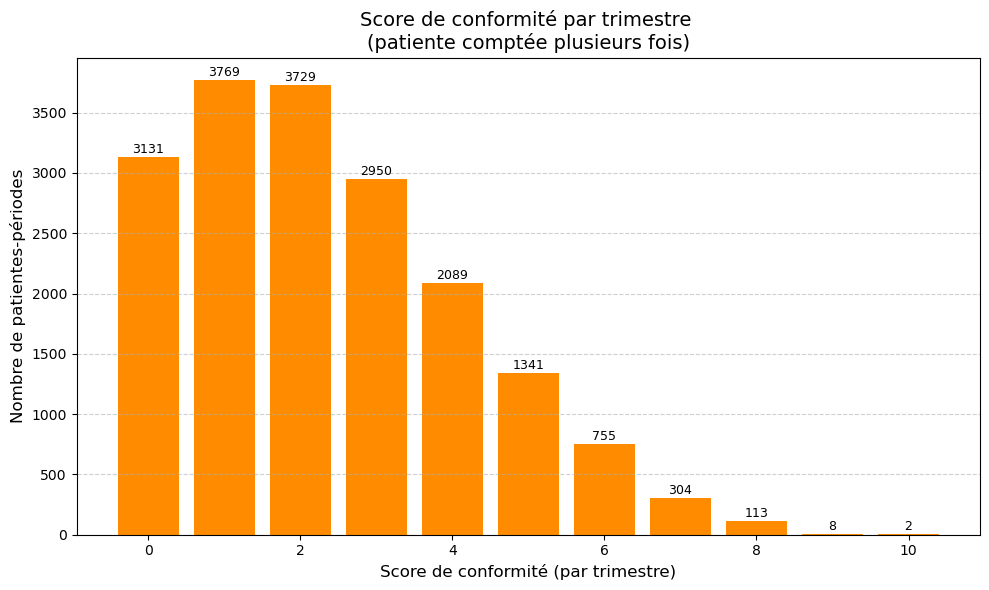

In [230]:
# Calcul du score de conformité
colonnes_conf = [col for col in df_resumé_par_periode.columns if col.startswith("conf_")]
df_resumé_par_periode["score_conformité"] = df_resumé_par_periode[colonnes_conf].sum(axis=1)

plt.figure(figsize=(10, 6))
counts_period = df_resumé_par_periode["score_conformité"].value_counts().sort_index()
bars = plt.bar(counts_period.index, counts_period.values, color='darkorange')

plt.title("Score de conformité par trimestre \n(patiente comptée plusieurs fois)", fontsize=14)
plt.xlabel("Score de conformité (par trimestre)", fontsize=12)
plt.ylabel("Nombre de patientes-périodes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


3769 périodes avec un score de 1 et 3131 périodes à score 0, soit aucun ou un seul acte réalisé pendant ces périodes , La majorité des patientes ne réalisent qu’un ou deux actes recommandés par période.


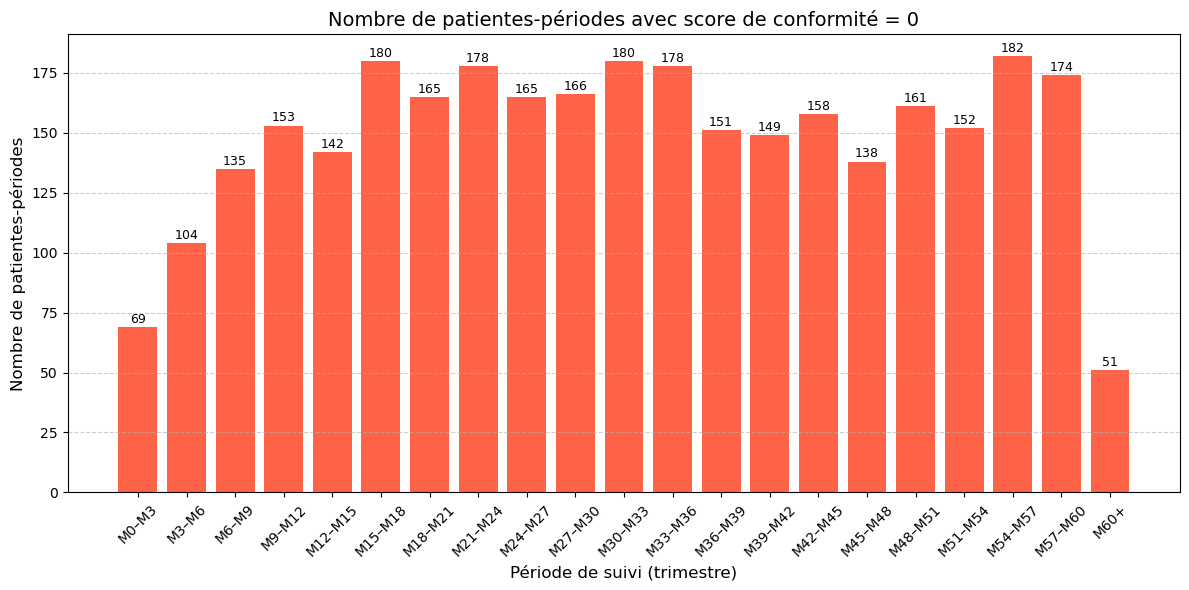

In [219]:

df_score_0 = df_resumé_par_periode[df_resumé_par_periode["score_conformité"] == 0]

score0_par_periode = df_score_0["periode_suivi"].value_counts()

valeurs_valides = [p for p in score0_par_periode.index if "60+" not in p]
ordre = sorted(valeurs_valides, key=lambda x: int(x[1:].split("–")[0]))

if "M60+" in score0_par_periode.index:
    ordre.append("M60+")

score0_par_periode = score0_par_periode.reindex(ordre)

plt.figure(figsize=(12, 6))
bars = plt.bar(score0_par_periode.index, score0_par_periode.values, color='tomato')

plt.title("Nombre de patientes-périodes avec score de conformité = 0", fontsize=14)
plt.xlabel("Période de suivi (trimestre)", fontsize=12)
plt.ylabel("Nombre de patientes-périodes", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


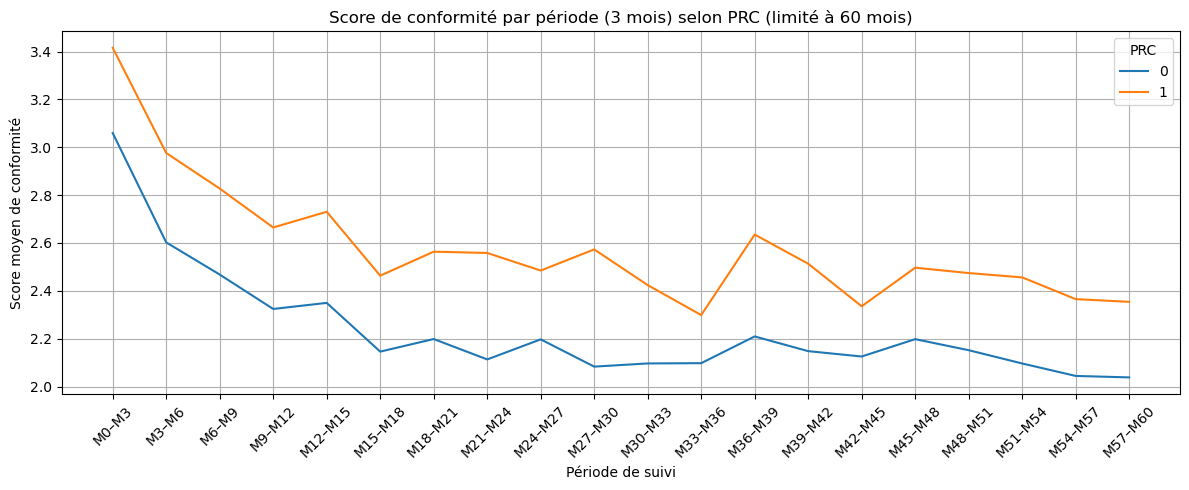

In [220]:
import seaborn as sns

df_plot = df_resumé_par_periode[df_resumé_par_periode["periode_suivi"] != "M60+"].copy()

ordre = sorted(df_plot["periode_suivi"].dropna().unique(), key=lambda x: int(x[1:].split("–")[0]))
df_plot["periode_suivi"] = pd.Categorical(df_plot["periode_suivi"], categories=ordre, ordered=True)
df_plot = df_plot.sort_values("periode_suivi")

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_plot,
    x="periode_suivi",
    y="score_conformité",
    hue="PRC",
    estimator="mean",
    ci=None
)
plt.title("Score de conformité par période (3 mois) selon PRC (limité à 60 mois)")
plt.xlabel("Période de suivi")
plt.ylabel("Score moyen de conformité")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


La conformité diminue dans le temps, mais les patientes PRC=1 restent légèrement plus engagées dans leur suivi.
Cela illustre un effet léger mais constant de la peur de récidive sur l'adhésion au suivi médical recommandé.

In [221]:
df_score_patient = df_resumé_par_periode.groupby("ID_PATIENT")[colonnes_conf].max().reset_index()

df_score_patient["score_conformité"] = df_score_patient[colonnes_conf].sum(axis=1)


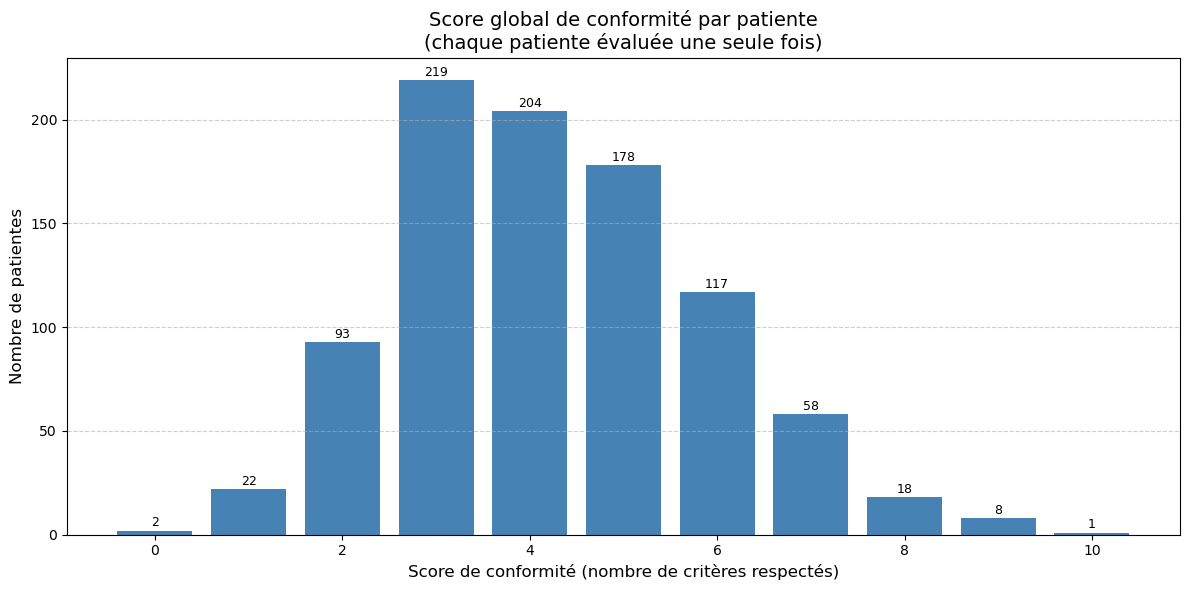

In [222]:

plt.figure(figsize=(12, 6))
counts = df_score_patient["score_conformité"].value_counts().sort_index()

bars = plt.bar(counts.index, counts.values, color='steelblue')

plt.title("Score global de conformité par patiente\n(chaque patiente évaluée une seule fois)", fontsize=14)
plt.xlabel("Score de conformité (nombre de critères respectés)", fontsize=12)
plt.ylabel("Nombre de patientes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


La majorité des patientes sont assez-bien suivies, avec un pic de score à 4 et 5 sur 11.


Globalement, le système assure un suivi pas mal à accepatble pour une large part des patientes.

Le problème n’est pas forcément qui est suivi, mais quand et à quelle régularité.

## En gros pour cette partie 

#### Le graphe orange montre que chaque trimestre est rarement complet (score 0 à 2 dominant),

#### Le graphe bleu montre que malgré cela, certaines patientes parviennent à cumulativement respecter 4 à 6 critères sur 5 ans, ce qui est logique.

## Traitement d'Excès d'actes médicaux 

In [223]:
seuils_3mois = {
    "Cons_Med_Gen": 1,
    "Cons_Spe": 1,
    "Mammographie": 0.25,
    "Ca_15_3": 0.25,
    "Fns": 0.25,
    "Bilan_Hepatique": 0.25,
    "Bilan_Lipidique": 0.25,
    "Echo_pelv": 0.25  # Conditionnel
}


In [225]:
for acte, seuil in seuils_3mois.items():
    col_name = f"excès_{acte}"
    if acte == "Echo_pelv":
        # Cas conditionnel : uniquement si Tamoxifen == 1
        df_resumé_par_periode[col_name] = df_resumé_par_periode.apply(
            lambda row: 1 if row["Tamoxifen"] == 1 and row.get(acte, 0) > seuil else 0, axis=1
        )
    elif acte in df_resumé_par_periode.columns:
        df_resumé_par_periode[col_name] = (df_resumé_par_periode[acte] > seuil).astype(int)
    else:
        df_resumé_par_periode[col_name] = 0  # si l'acte est absent


In [226]:
colonnes_excès = [f"excès_{acte}" for acte in seuils_3mois.keys()]
df_resumé_par_periode["score_excès"] = df_resumé_par_periode[colonnes_excès].sum(axis=1)


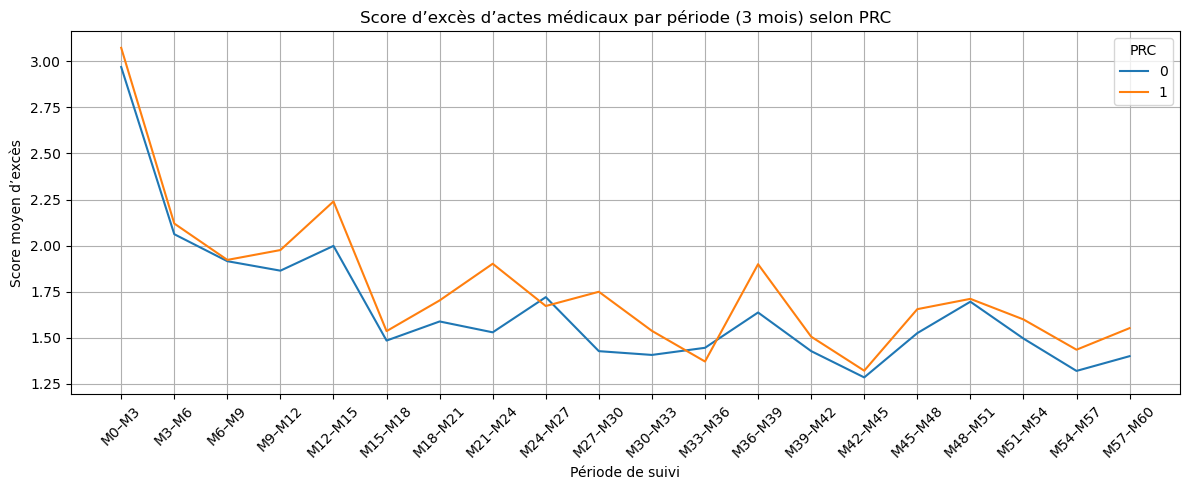

In [227]:
périodes_valides = [x for x in df_resumé_par_periode["periode_suivi"].dropna().unique() if "60+" not in x]

ordre = sorted(périodes_valides, key=lambda x: int(x[1:].split("–")[0]))

if "M60+" in df_resumé_par_periode["periode_suivi"].values:
    ordre.append("M60+")

df_resumé_par_periode["periode_suivi"] = pd.Categorical(df_resumé_par_periode["periode_suivi"], categories=ordre, ordered=True)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_resumé_par_periode[df_resumé_par_periode["periode_suivi"] != "M60+"],
    x="periode_suivi",
    y="score_excès",
    hue="PRC",
    estimator="mean",
    ci=None
)
plt.title("Score d’excès d’actes médicaux par période (3 mois) selon PRC")
plt.xlabel("Période de suivi")
plt.ylabel("Score moyen d’excès")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [228]:
from scipy.stats import shapiro

groupe_0 = df_resumé_par_periode[df_resumé_par_periode["PRC"] == 0]["score_excès"]
groupe_1 = df_resumé_par_periode[df_resumé_par_periode["PRC"] == 1]["score_excès"]

# Tester la normalité
stat0, p0 = shapiro(groupe_0.sample(500, random_state=1))
stat1, p1 = shapiro(groupe_1.sample(500, random_state=1))

print(f"Shapiro PRC = 0: p = {p0:.4f}")
print(f"Shapiro PRC = 1: p = {p1:.4f}")


stat, p = mannwhitneyu(groupe_0, groupe_1, alternative='two-sided')
print(f"Mann-Whitney U Test : U = {stat}, p-value = {p:.4f}")



Shapiro PRC = 0: p = 0.0000
Shapiro PRC = 1: p = 0.0000
Mann-Whitney U Test : U = 24101651.5, p-value = 0.0003


In [229]:
print("Médiane PRC = 0 :", groupe_0.median())
print("Médiane PRC = 1 :", groupe_1.median())


Médiane PRC = 0 : 1.0
Médiane PRC = 1 : 1.0


### Pourquoi le score d’excès ?

Le score d’excès synthétise le nombre d’actes réalisés au-delà des seuils recommandés par le protocole PPS. Il permet d’identifier une possible surmédicalisation. Nous l’avons utilisé pour évaluer si le statut PRC est associé à un suivi potentiellement plus intensif que recommandé.

### Choix du test

Le test de Shapiro-Wilk montre que `score_excès` ne suit pas une distribution normale. Par conséquent, nous utilisons le test de Mann-Whitney U pour Évaluer si l'une des deux distributions tend à produire des valeurs plus grandes que l'autre.



### Résultat

- U = 24,101,651.5
- p-value = 0.0003

Cela indique une différence statistiquement significative dans la distribution du score d’excès selon le PRC. Les patientes avec PRC ont tendance à avoir un suivi plus intensif.
